In [1]:
import os
import glob
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
from collections import defaultdict
from smplx import SMPLX
from tqdm import tqdm

In [2]:
poses_files = glob.glob(
    "/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe/video_*/*.npz"
)
random.shuffle(poses_files)

print(f"{len(poses_files)} fichiers trouvés")

95754 fichiers trouvés


In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SMPLX_MODEL_PATH = (
    "/home/natsalaz/Documents/thesegit/5-Merge/mergepp/data/smplx_models/smplx"
)

smplx_model = SMPLX(
    model_path=SMPLX_MODEL_PATH,
    gender="NEUTRAL_2020",
    ext="npz",
    num_expression_coeffs=100,
    use_face_contour=False,
    create_expression=True,
    create_jaw_pose=True,
    create_global_orient=True,
    create_body_pose=True,
    create_betas=True,
    create_left_hand_pose=True,
    create_right_hand_pose=True,
    use_pca=False,
).to(DEVICE)

In [4]:
def smplx_forward(global_orient, body_pose, transl):
    N = global_orient.shape[0]

    body_part = body_pose[:, :63]
    jaw = body_pose[:, 63:66]
    leye = body_pose[:, 66:69]
    reye = body_pose[:, 69:72]
    lhand = body_pose[:, 72:117]
    rhand = body_pose[:, 117:162]

    betas = torch.zeros((N, 10), device=DEVICE)
    expr = torch.zeros((N, 100), device=DEVICE)

    with torch.no_grad():
        out = smplx_model(
            global_orient=torch.tensor(
                global_orient, device=DEVICE, dtype=torch.float32
            ),
            body_pose=torch.tensor(body_part, device=DEVICE, dtype=torch.float32),
            jaw_pose=torch.tensor(jaw, device=DEVICE, dtype=torch.float32),
            leye_pose=torch.tensor(leye, device=DEVICE, dtype=torch.float32),
            reye_pose=torch.tensor(reye, device=DEVICE, dtype=torch.float32),
            left_hand_pose=torch.tensor(lhand, device=DEVICE, dtype=torch.float32),
            right_hand_pose=torch.tensor(rhand, device=DEVICE, dtype=torch.float32),
            transl=torch.tensor(transl, device=DEVICE, dtype=torch.float32),
            betas=betas,
            expression=expr,
        )
    return out.joints.cpu().numpy()  # (T, J, 3)

In [5]:
def kinematic_metrics(joints, fps):
    dt = 1.0 / fps

    vel = np.diff(joints, axis=0) / dt
    acc = np.diff(vel, axis=0) / dt

    vel_norm = np.linalg.norm(vel, axis=-1)  # (T-1, J)
    acc_norm = np.linalg.norm(acc, axis=-1)

    amp = joints.max(axis=0) - joints.min(axis=0)
    amp_norm = np.linalg.norm(amp, axis=-1)

    return vel_norm, acc_norm, amp_norm

In [6]:
all_velocities = []
all_amplitudes = []

for path in tqdm(poses_files[: len(poses_files)], desc="Processing files"):
    data = np.load(path, allow_pickle=True)
    person_keys = [k for k in data.files if k.startswith("body_")]

    for key in person_keys:
        body = data[key].item()
        if "poses" not in body or "trans" not in body:
            continue

        poses = body["poses"]
        transl = body["trans"]
        fps = body.get("fps", 30)

        global_orient = poses[:, :3]
        body_pose = poses[:, 3:]

        joints = smplx_forward(global_orient, body_pose, transl)

        vel_norm, _, amp_norm = kinematic_metrics(joints, fps)

        all_velocities.append(vel_norm.reshape(-1))
        all_amplitudes.append(amp_norm)

Processing files:  39%|███▉      | 37169/95754 [3:19:22<5:14:15,  3.11it/s] 


KeyboardInterrupt: 

In [ ]:
all_velocities = np.concatenate(all_velocities)
all_amplitudes = np.concatenate(all_amplitudes)

all_velocities = all_velocities[np.isfinite(all_velocities)]

print("Total velocity samples:", all_velocities.shape[0])
print("Total joints amplitudes:", all_amplitudes.shape[0])

Total velocity samples: 4486402
Total joints amplitudes: 25400


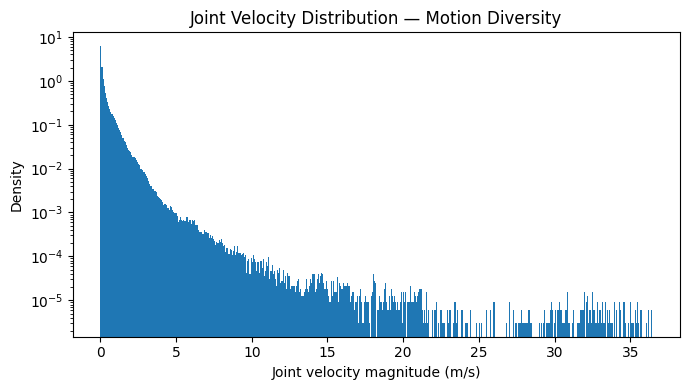

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(all_velocities, bins=500, density=True)
plt.xlabel("Joint velocity magnitude (m/s)")
plt.ylabel("Density")
plt.title("Joint Velocity Distribution — Motion Diversity")
plt.yscale("log")
plt.tight_layout()
plt.show()

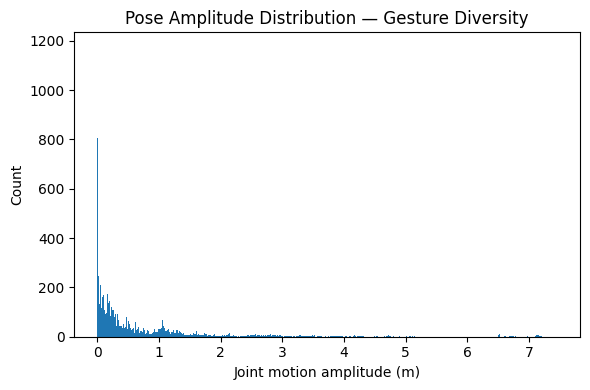

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(all_amplitudes, bins=2000)
plt.xlabel("Joint motion amplitude (m)")
plt.ylabel("Count")
plt.title("Pose Amplitude Distribution — Gesture Diversity")
plt.tight_layout()
plt.show()

In [ ]:
print("=== MOTION DIVERSITY STATS ===")

print("Velocity mean :", all_velocities.mean())
print("Velocity variance :", all_velocities.var())

p25, p50, p75 = np.percentile(all_velocities, [25, 50, 75])
print("Velocity percentiles:", p25, p50, p75)

a25, a75 = np.percentile(all_amplitudes, [25, 75])
print("Amplitude low / high:", a25, a75)

=== MOTION DIVERSITY STATS ===
Velocity mean : 0.30530787
Velocity variance : 0.41408885
Velocity percentiles: 0.027554649859666824 0.09167874604463577 0.3141863942146301
Amplitude low / high: 0.09278366714715958 0.9244368523359299
